# Introduction

In this notebook two different <span style="color: orange;">unsupervised clustering</span> techniques available in the sci-kit learn library (https://scikit-learn.org/stable/) are applied to <span style="color: orange;">CRISM MTRDR I/F data</span> in the NIR range (1-2.6 microns). 

The featured algorithms are: 
1) K-means;
2) Gaussian mixture models.

Clustering is carried out on the I/F cube after a series of pre-processing steps and dimensionality reduction. Dimensionality of the data is here reduced in two steps: at first, the data is reduced through **Principal Component Analysis (PCA)**, then, the results are given as input to UMAP. **UMAP (Uniform Manifold Approximation and Projection)** is a manifold-based nonlinear dimensionality reduction approach. 

Clustering results can be visualized within the Notebook or can be exported as a georeferenced .tif file for use with GIS softwares. The Notebook also allows to extract and plot the median spectra of the clusters. The spectra can be extracted either directly from the I/F cube or from a *ratioed* version of the same cube. A ratioed data cube is a cube where all the spectra are ratioed to a featureless spectrum (or the mean/median of several featureless spectra) within the same scene. The ratioed cube can be obtained using the workflow in the CRISM_ratioed_cube_MTRDR.ipynb notebook.

# Import

In [10]:
#-----------python libraries-----------

#numpy
import numpy as np

#pandas
import pandas as pd

#plotting
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import colorcet as cc
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
%matplotlib inline

#open envi image
from spectral import open_image

#image stretching
from skimage import exposure

#clustering
from sklearn import decomposition, preprocessing, cluster, mixture
import umap

#computing time
import time
#folder/file management
import os
import pathlib
from pathlib import Path

#-----------external custom functions-----------
from find_nearest import find_nearest #to find nearest value in a numpy array 
from georef import read_envi_georef, write_cluster_geotiff #for georeferencing and exporting tiff files


# Open image

In [5]:
#path
#path_if = 'data/frt0000bef5_07_if165j_mtr3.hdr' #put here the path of your data
path_if = 'data/frt00009b5a_07_if165j_mtr3.hdr' #put here the path of your data

#opening I/F file
img = open_image(path_if)
wavelength = np.array(img.metadata['wavelength']).astype(float)

#if data is in micron you should convert to nm, uncomment this line if this is your case
#wavelength = wavelength*1000.

#getting the filename from path
filename = os.path.splitext(os.path.basename(path_if))[0]

#converting img to simple array and putting no-values to NaN
nan_img = np.copy(img[:,:,:])
nan_img[nan_img>10]=np.nan

# Cube visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


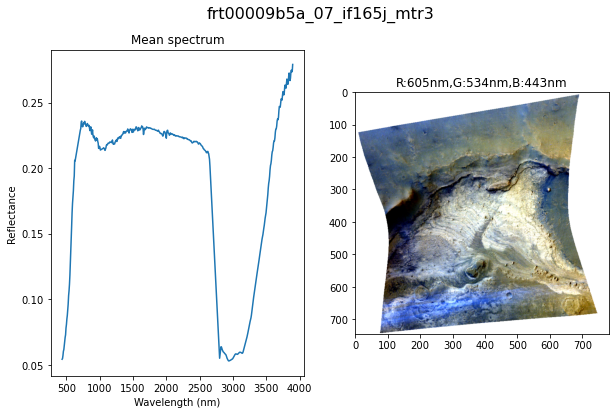

In [6]:
#computing mean spectrum
mean_spec = np.nanmean(nan_img.reshape(-1,nan_img.shape[-1]), axis = 0)

#RGB true color image
wav_channels = [26,15,1] #600nm,530nm,440nm
wav_channels_text = ','.join([f'{c}:{w:.0f}nm' for c,w in zip(['R','G','B'],wavelength[wav_channels])]) #channels text for plot
#slicing to get RGB
RGB = img[:,:,wav_channels]

#contrast stretching: 
for ind, ch in enumerate (RGB.T):
    #masking no-data values
    ch_mask = ch != 65535. 
    #2nd and 98th percentile ignoring no-data values (if present)
    p2, p98 = np.nanpercentile(ch[ch_mask], (2, 98)) 
    RGB[:,:,ind] = exposure.rescale_intensity(ch, in_range=(p2, p98)).T

#-----------plots-----------
fig, axs = plt.subplots(ncols=2,figsize=[10,6])
fig.suptitle(filename, fontsize = 16)

#mean spectrum (mean over the whole scene) plot
axs[0].plot(wavelength, mean_spec)
#title, labels...
axs[0].set_title('Mean spectrum')
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Reflectance')

#image plot
axs[1].set_title(wav_channels_text)
axs[1].imshow(RGB)

plt.show()

#uncomment to save the image
#plt.savefig('crism_scene_'+filename,dpi=300)

# Preprocessing

There is a certain number of pre-processing steps to do before applying any clustering algorithm.

1) No-data/invalid values are removed (any value in the reflectance cube which is smaller than 0 or greater than 1)
2) Wavelength range is restricted between 1 and 2.6 microns. 
3) Data is filtered for artefacts: a) 1.645-1.704 (filter boundary artefact); b) 1.948-2.060 (CO2 artefact)




In [ ]:
#create a pandas dataframe
df = pd.DataFrame(img[:,:,:].reshape(-1,img.shape[-1]),
            columns=wavelength/1000.
            )
print("-> df shape (initial data shape): %s" % str(df.shape))
df[(df > 1) | (df < 0)] = np.nan #no-data/invalid values are put as NaNs


#->remove no-data values and resize the data to a smaller wavelength range
start_wav, stop_wav = 1.0, 2.6 #wavelengths between 1.0 and 2.6 microns
start_wav_ind, stop_wav_ind = find_nearest(start_wav,df.columns),find_nearest(stop_wav,df.columns) #get indexes
df_nonan = df.dropna(axis=0,how='all').iloc[:,start_wav_ind:stop_wav_ind] #drop NaN values and restrict wav. range
print("\nno-data values removed")
print("data is restricted between {}-{} um".format(start_wav, stop_wav))


#->remove ranges with artefacts
#----1.7 filter artefact:---- 
wv1_min_index = 169
wv1_max_index = 178
start_1 = wavelength[wv1_min_index]*0.001
stop_1 = wavelength[wv1_max_index]*0.001
#----CO2 artefact----
wv2_min_index = 215
wv2_max_index = 232
start_2 = wavelength[wv2_min_index]*0.001
stop_2 = wavelength[wv2_max_index]*0.001

print('filter artefact: {:.3f}-{:.3f} um;\nCO2 artefact: {:.3f}-{:.3f} um\n'.format(start_1, 
                                                                                    stop_1, 
                                                                                    start_2, 
                                                                                    stop_2))
df_nonan.loc[:,start_1:stop_1] = np.nan #1.7 filter artefact
df_nonan.loc[:,start_2:stop_2] = np.nan #CO2 artefact
#dropping NaN values on the columns (artefact gaps)
df_nonan = df_nonan.dropna(axis=1, how='all')
#-----------------------------------

#check shape
print("-> df_nonan shape (final data shape): %s" % str(df_nonan.shape))

-> df shape (initial data shape): (581064, 489)

no-data values removed
data is restricted between 1.0-2.6 um
filter artefact: 1.645-1.704 um;
CO2 artefact: 1.948-2.060 um

-> df_nonan shape (final data shape): (394890, 211)


<AxesSubplot:title={'center':'Sample spectra from df_nonan'}>

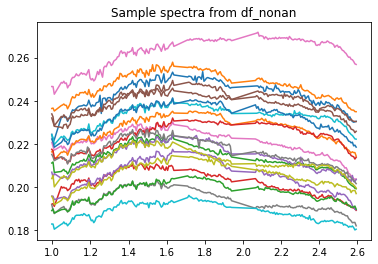

In [8]:
#This plot visualizes random spectra from the data (gaps are connected by a straight line)
df_nonan.sample(20).T.plot(title = 'Sample spectra from df_nonan', legend=None)

## Save df and df_nonan

In [9]:
#save df and df_nonan

#---> this data is to be used in the silhouette script, save this only once,
#df and df_nonan will be the same for every clustering algorithm

df.to_pickle("output/df_"+filename+".pkl")
df_nonan.to_pickle("output/df_nonan_"+filename+".pkl")

# Dimensionality reduction

## Part 1: Principal Component Analysis (PCA)

The large number of bands in hyperspectral cubes make it a very high-dimensional dataset, impacting the performance of the clustering algorithms. Principal component analysis (PCA) is a simple solution to reduce the dimensionality of the data, improving the quality of clustering. 

In [ ]:
pc0=False #False if the first principal component (pc0) is not removed (will become True if you run the cell which removes pc0)
X = df_nonan.values #data array

n_components = 6 #number of pca components
pca = decomposition.PCA(n_components=n_components)
pca.fit(X)
n_components = pca.n_components_
X_pca = pca.transform(X)


print('X.shape               : {}\n'
      'X_pca.shape           : {}\n'
      'pca.components_.shape : {}'.format(X.shape, X_pca.shape, pca.components_.shape))

print("              variance       var_ratio      cum_var_ratio")
for i in range(n_components):
    print("Component %2s: %12.10f   %12.10f   %12.10f" % (i, pca.explained_variance_[i], 
                                                          pca.explained_variance_ratio_[i], 
                                                          np.cumsum(pca.explained_variance_ratio_)[i]))

X.shape               : (394890, 211)
X_pca.shape           : (394890, 6)
pca.components_.shape : (6, 211)
              variance       var_ratio      cum_var_ratio
Component  0: 0.1466776282   0.9925562739   0.9925562739
Component  1: 0.0006721542   0.0045484160   0.9971047044
Component  2: 0.0002019716   0.0013667266   0.9984714389
Component  3: 0.0000496251   0.0003358095   0.9988072515
Component  4: 0.0000416639   0.0002819366   0.9990891814
Component  5: 0.0000334594   0.0002264172   0.9993156195


initial data size:(581064, 489)
filtered data size:(394890, 211)
data size after PCA:(394890, 6)



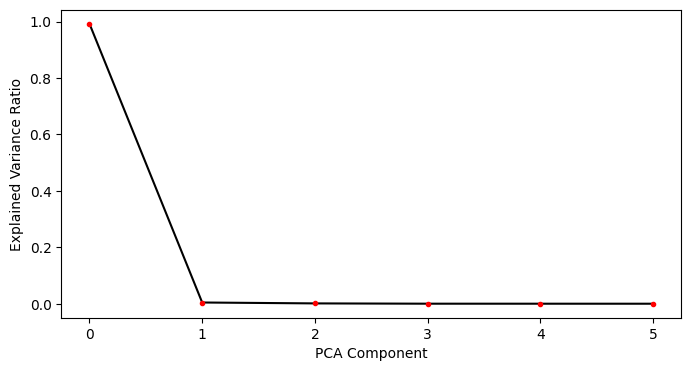

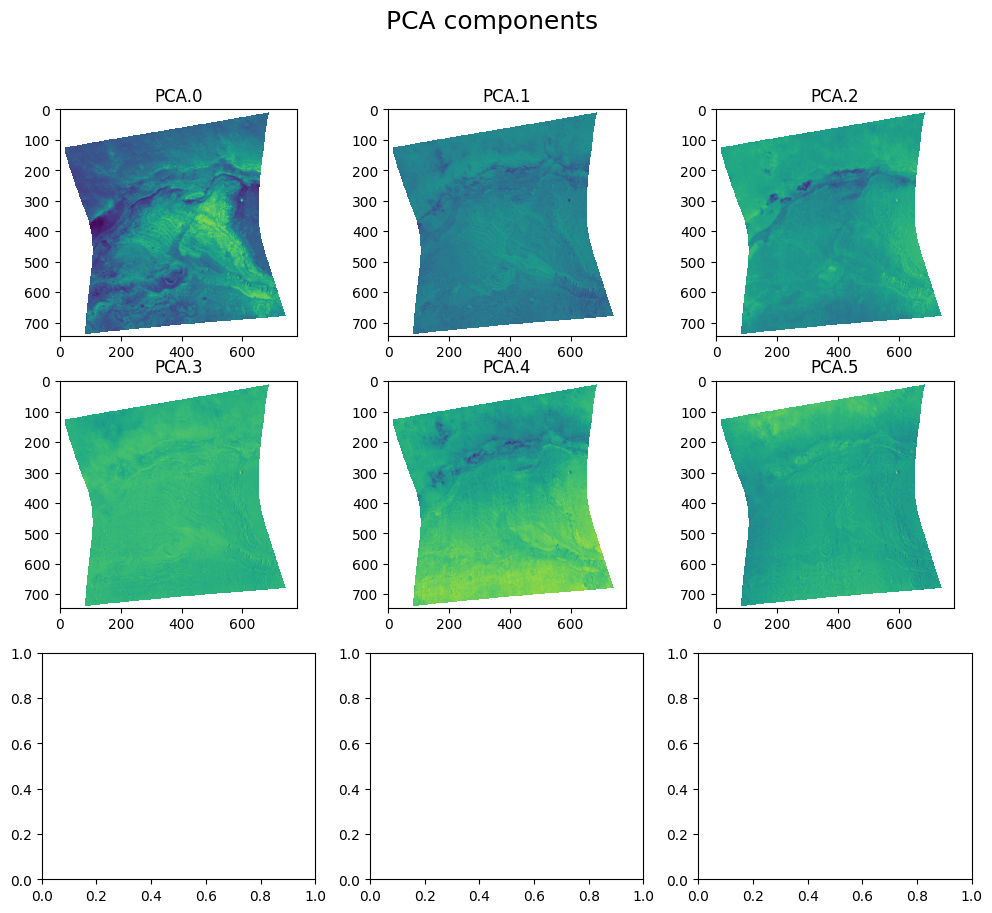

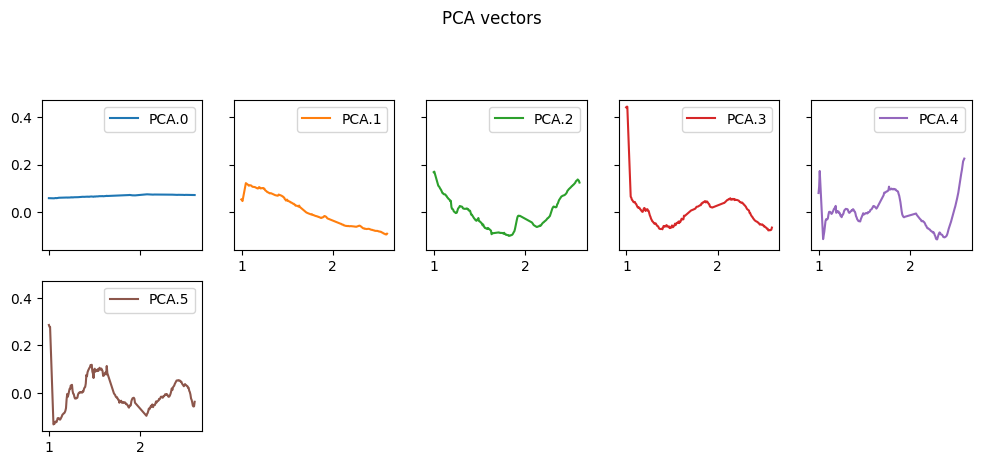

In [ ]:
#visualize pca components

print("initial data size:{}\nfiltered data size:{}\ndata size after PCA:{}\n".format(df.shape,df_nonan.shape,X_pca.shape)) #some info on data shape
    
#---------plot of explained variance---------
components_shift = 0 #if components_shift=1 first pca component is not shown in the figure.
fig = plt.figure(figsize=(8,4))
ax = plt.subplot()
ax.plot(np.arange(pca.n_components-components_shift)+components_shift, pca.explained_variance_ratio_[components_shift:], c="black")
ax.plot(np.arange(pca.n_components-components_shift)+components_shift, pca.explained_variance_ratio_[components_shift:], "r.")

ax.set_xlabel("PCA Component")  
ax.set_ylabel("Explained Variance Ratio") 
#ax.set_yscale('log') #uncomment to set logarithmic scale on y axis

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) #ensure axis only shows integers
    
#---------plot pca components---------
plot_df = pd.DataFrame(index=df.index) #create a plot dataframe

for cmp in range(pca.n_components): #set column names
    plot_df[f'PCA.{cmp}'] = np.nan 
    
plot_df.loc[df_nonan.index] = X_pca #fill columns

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=[12,10]) #rows and columns can be manually adjusted based on n_components
fig.suptitle("PCA components", size = 18)
axs = axs.flatten()
    
for ind, ax in enumerate(axs):
    if ind < n_components:
        ax.imshow(plot_df.iloc[:,ind].values.reshape(img.shape[:-1]))
        ax.set_title(plot_df.columns[ind])
    

#---------plot pca vectors--------- 
pca_vectors = pd.DataFrame(columns=df_nonan.columns,
                        index=[ f'PCA.{cmp}' for cmp in range(pca.n_components)],
                        data=pca.components_)

pca_vectors.T.plot(subplots=True,figsize=[12,9], layout = (4,5), sharey = True, title = 'PCA vectors')

plt.show()  


### Remove first component of PCA (suggested) - run only once!
Removing the first component of the PCA from the data will remove the dependency on reflectance of the clustering algorithms. This will help the algorithms to focus more on bands and slope differences rather than the differences in reflectance levels

In [ ]:
#first component of X_pca is removed (run this cell only once!)
X_pca = X_pca[:,1:]
print('First component of PCA removed! X_pca.shape =', X_pca.shape)
pc0 = True

First component of PCA removed! X_pca.shape = (394890, 5)


## Part 2: UMAP
Umap stands for "Uniform Manifold Approximation and Projection for Dimension Reduction" and is a non linear dimensionality reduction technique.
More info on how this works can be found here: https://umap-learn.readthedocs.io/en/latest/# and here: https://pair-code.github.io/understanding-umap/

In [ ]:
#short function to compute umap
def compute_UMAP(umap_data, 
                 neighbors, 
                 mindistances): 
                     
    X = umap.UMAP(n_neighbors=neighbors, min_dist = mindistances).fit_transform(umap_data)
                     
    return X

C:\Users\francesc0\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Compute umap grid

In this part of code you can run umap algorith with different initial parameters (a grid of different nearest neighbours and minimum distance values). This will help you explore how umap maps the data and help you choose the best values for the nearest neighbor and minimum distance. Computed values will be saved in a separate file so that you can access them later.

<font color='orange'>Careful! This part may take several tens of minutes to run, **you should run it only once** and then use the saved data for the next part of the code (clustering algorithm application).</font>

In [ ]:
#range of nearest neighbors and minimum distances to try

neighbors = [25, 50, 100] #the bigger this number the more computationally expensive the algorithm, max 500 suggested
mindistances = [0.2, 0.5, 0.8]

#umap is applied to PCA data
umap_data = X_pca

#compute and write data
for n in neighbors:
    for d in mindistances:

        cached_umap = pathlib.Path('output/umap/'+filename+'_umap_embedding_neighbors-{}_mindist-{}.npy'.format(n,d)) #data is saved in this folder
        if cached_umap.is_file():
            print('File with neigh={}, mindist={} already exists'.format(n,d))
            
        else: 
            print('Computing UMAP for neigh={}, mindist={}...'.format(n,d))
            results = compute_UMAP(umap_data, n, d)
            np.save(cached_umap,results) 
            del results

print('done!')

Computing UMAP for neigh=25, mindist=0.2...
Computing UMAP for neigh=25, mindist=0.5...
Computing UMAP for neigh=25, mindist=0.8...
Computing UMAP for neigh=50, mindist=0.2...
Computing UMAP for neigh=50, mindist=0.5...
Computing UMAP for neigh=50, mindist=0.8...
Computing UMAP for neigh=100, mindist=0.2...
Computing UMAP for neigh=100, mindist=0.5...
Computing UMAP for neigh=100, mindist=0.8...
done!


### Load UMAP grid
Load your UMAP grid if you already have one computed with the code above.

In [ ]:
#load data
import pathlib
from pathlib import Path

neighbors = [25, 50, 100]
mindistances = [0.2, 0.5, 0.8]
results_dict = {}

for n in neighbors:
    for d in mindistances:  
        cached_umap = pathlib.Path('output/umap/'+filename+'_umap_embedding_neighbors-{}_mindist-{}.npy'.format(n,d))
        results_dict[(n,d)] = np.load(cached_umap)     


label = [(n,d) for n in neighbors for d in mindistances]

### Plot loaded UMAP grid

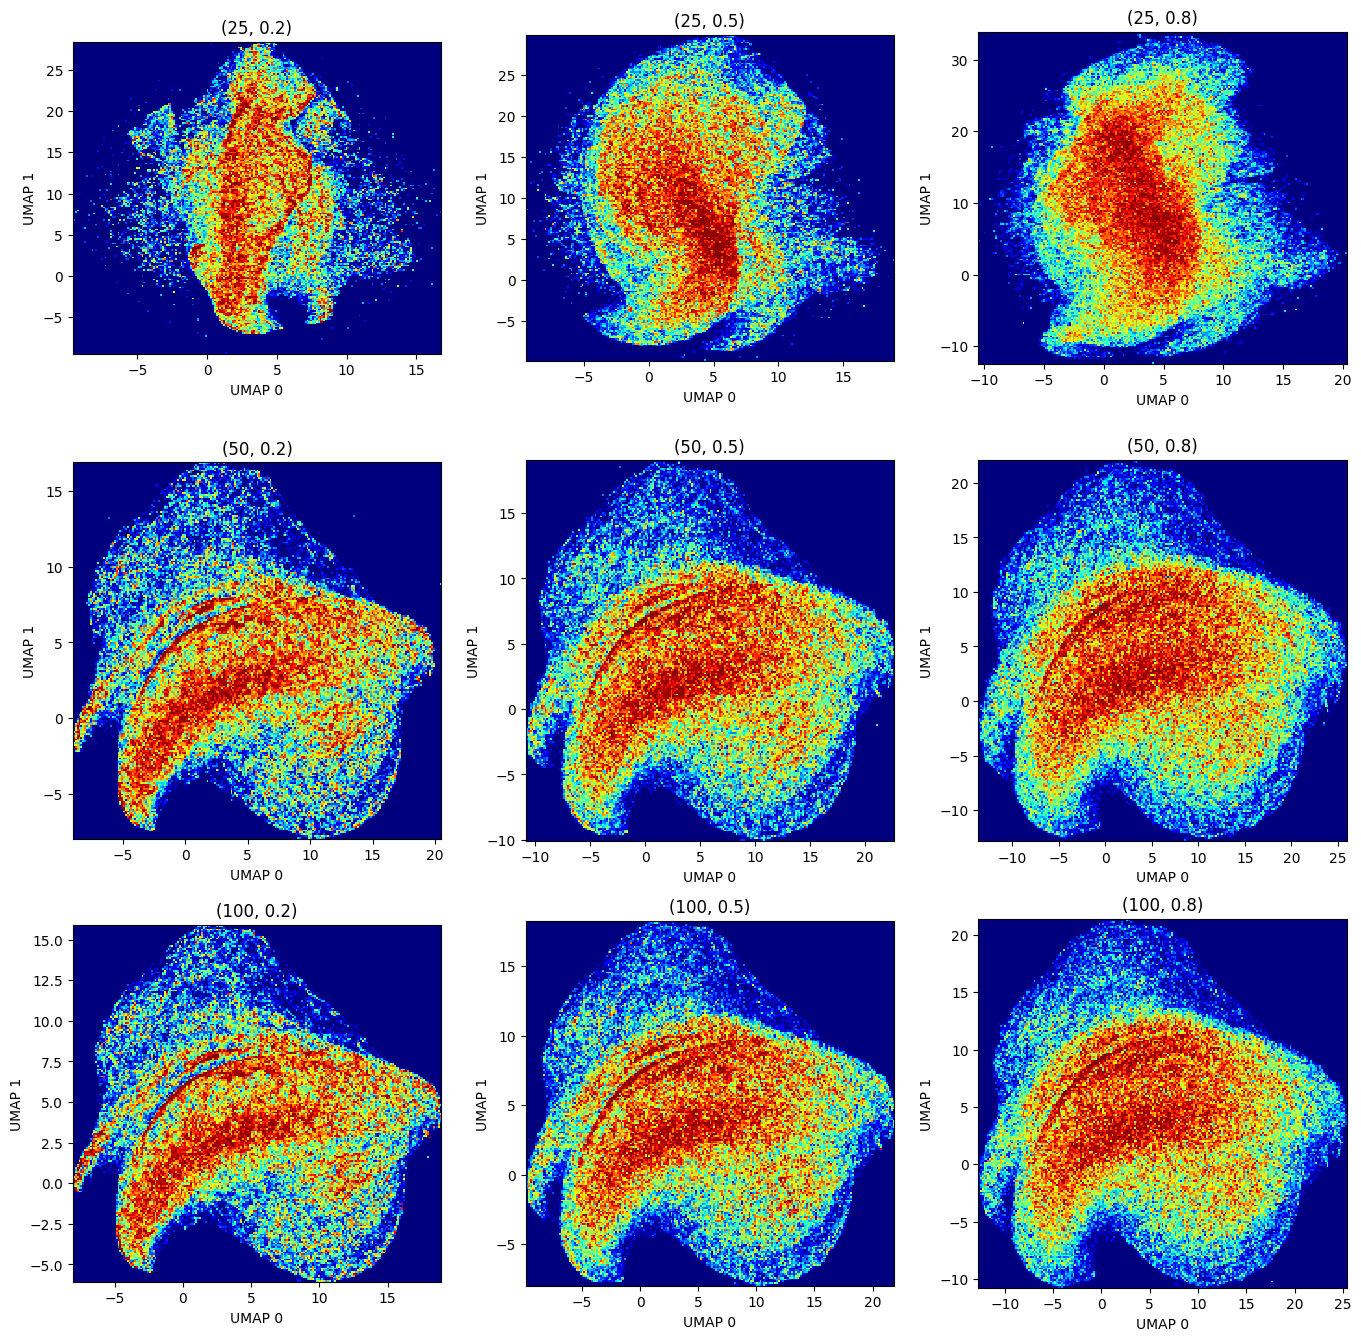

In [ ]:
fig, axs = plt.subplots(3,3, figsize=(14,14))
axs = axs.flatten()
fig.tight_layout(pad = 3)

#define the number of bins
nxbins = 200
nybins = 200
nbins = 200

for i, keys in enumerate(label):
    data = results_dict[keys]
    X = data[:,0]
    Y = data[:,1]

    #find the min max of data
    xmin = min(X)
    xmax = max(X)
    ymin = min(Y)
    ymax = max(Y)

    #plot

    xbins = np.linspace(start = xmin, stop = xmax, num = nxbins)
    ybins = np.linspace(start = ymin, stop = ymax, num = nybins)
    xcenter = (xbins[0:-1]+xbins[1:])/2.0
    ycenter = (ybins[0:-1]+ybins[1:])/2.0
    aspectratio = 1.0*(xmax - 0)/(1.0*ymax - 0)
 
    H, xedges,yedges = np.histogram2d(Y,X,bins=(ybins,xbins))

    axs[i].imshow(exposure.equalize_hist(H), extent=[xmin,xmax,ymin,ymax], interpolation='nearest', origin='lower',aspect=aspectratio, cmap = 'jet')

    #set title
    axs[i].set_title(keys)
    
    #plot axes labels
    axs[i].set_xlabel('UMAP 0',fontsize=10)
    axs[i].set_ylabel('UMAP 1',fontsize=10)    

### Choose UMAP result
Choose the best nearest neighbor/minimum distance set based on the grid above. This data will be passed to the clustering algorithms.

In [20]:
#chosen parameters
n_neigh = 100
min_dist = 0.2
#get data from results dictionary
X_umap = results_dict[(n_neigh,min_dist)]
#print info
print('Nearest neighbours:{}; Minimum distance:{}'.format(n_neigh, min_dist))
print("initial data size:{}\nfiltered data size:{}\ndata size after PCA:{}\ndata size after UMAP:{}".format(df.shape,
                                                                                                            df_nonan.shape,
                                                                                                            X_pca.shape,
                                                                                                            X_umap.shape))

Nearest neighbours:100; Minimum distance:0.2
initial data size:(581064, 489)
filtered data size:(394890, 211)
data size after PCA:(394890, 5)
data size after UMAP:(394890, 2)


# Clustering and visualization of results

## Scaler
Data needs to be scaled before passing them to the clustering algorithm -> https://scikit-learn.org/stable/modules/preprocessing.html

Here the "standard scaler" is used -> https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py

In [22]:
X_to_scale = X_umap 
scaler = preprocessing.StandardScaler().fit(X_to_scale)
X_scaled = scaler.transform(X_to_scale)

#scaled data has zero mean and unit variance
print('Scaled data info:\n')
print('Mean:',X_scaled.mean(axis=0))
print('Std:',X_scaled.std(axis=0))


Scaled data info:

Mean: [-2.3925113e-06 -4.2544993e-06]
Std: [0.99993587 0.99990517]


### Save scaled data

In [ ]:
#if you want to save the scaled data, run this cell
if pc0 == True:
    np.save('output/X_scaled_PCA' + str(n_components) + '-1_+UMAP_' + filename + '.npy', X_scaled) #PCA - 1st component
if pc0 == False:
    np.save('output/X_scaled_PCA' + str(n_components) + '+UMAP_' + filename + '.npy', X_scaled) #PCA - all components

## Clustering 
You can choose between k-means algorithm (https://scikit-learn.org/stable/modules/clustering.html#k-means) and gaussian mixture models (https://scikit-learn.org/stable/modules/mixture.html#mixture)

Uncomment the relevant part

In [ ]:
#Here you can load the scaled data you saved before. 
#This is useful in case you don't want to go through all the preprocessing and dimensionality reduction steps multiple times between different runs.
n_components = 6 #put here the original PCA components!
X_scaled = np.load('output/X_scaled_PCA' + str(n_components) + '-1_+UMAP_' + filename + '.npy') #put your chosen path here (PCA-1st component)
#X_scaled = np.load('output/X_scaled_PCA' + str(n_components) + '+UMAP_' + filename + '.npy') #put your chosen path here (all PCA components)

In [ ]:
#----------- K-means -----------------

classifier = 'K-Means'
n_clusters = 11

#computation time start
start_time = time.time()

#K-means estimator instance + classify scaled data
k_means = cluster.KMeans(n_clusters=n_clusters, init = 'k-means++', n_init=1, random_state=1111).fit(X_scaled)
labels = k_means.labels_
print('k_means.inertia_ : ',k_means.inertia_)

#computation time end
end_time = time.time()
computation_time = end_time - start_time
#print computation time
print("Computation time:", computation_time, "seconds")




#------------ Gaussian Mixture -------------

'''

classifier = 'Gaussian Mixture'
n_clusters = 11

#computation time start
start_time = time.time()

#choose from: full, tied, diag, spherical 
covariance_type = 'full'
#choose from: kmeans, k-means++, random, random_from_data
init_params = 'kmeans'
g_mixture = mixture.GaussianMixture(n_components=n_clusters, random_state=0, covariance_type = covariance_type, init_params = init_params)
labels = g_mixture.fit_predict(X_scaled) 

#computation time end
end_time = time.time()
computation_time = end_time - start_time
#print computation time
print("Computation time:", computation_time, "seconds")

'''

k_means.inertia_ :  81532.5625
Computation time: 0.19745874404907227 seconds


'\n\nfrom sklearn import mixture\n\nclassifier = \'Gaussian Mixture\'\nn_clusters = 11\n\n#computation time start\nstart_time = time.time()\n\n#choose from: full, tied, diag, spherical \ncovariance_type = \'full\'\n#choose from: kmeans, k-means++, random, random_from_data\ninit_params = \'kmeans\'\ng_mixture = mixture.GaussianMixture(n_components=n_clusters, random_state=0, covariance_type = covariance_type, init_params = init_params)\nlabels = g_mixture.fit_predict(X_scaled) \n\n#computation time end\nend_time = time.time()\ncomputation_time = end_time - start_time\n#print computation time\nprint("Computation time:", computation_time, "seconds")\n\n'

## Visualize results from clusters

### Relabelling of features with centroids 
Normally, clustering algorithms assign labels to clusters randomly.
In this part of the code you can change how the labels are assigned to the clusters.


--> Labels are re-assigned based on the reflectance value at a chosen wavelength of each cluster's mean spectrum. If the generated clusters are similar between k-Means and GMM, colors should -mostly- stay the same allowing the user to easily compare the different methods.

The code is adapted from its original version implemented here https://gist.github.com/kidpixo/6ec6c6c575e19b09da3d2207efa38b24

In [ ]:
y = df_nonan.groupby(labels).mean().values #get the mean spectrum of each cluster

feature = 2.5 #choose the feature (wavelength) based on which you want to rearrange the labels
feature_index = find_nearest(feature, df_nonan.columns.values)  #get the corresponding index
centroids_sorting_index = np.argsort(y[:, feature_index]) #get index that sorts y at the chosen feature 
centroids_sorted_labels = np.argsort(centroids_sorting_index) #array with the sorted labels 

#change the classes with the new integers 
labels = pd.Series(labels).map(dict(zip(np.arange(n_clusters), centroids_sorted_labels))).values.squeeze()

#visualize old and new indexes
print(f'index for label sort: index : {feature_index} - wav : {df_nonan.columns[feature_index]:1.3f} um')
print(f'ind : y_feat > new_index')
for i, yf, ni in zip(range(len(y[:, feature_index])),y[:,feature_index], centroids_sorted_labels):
    print(f'{i:3} : {yf:2.3f} > {ni:>4}')

#build the df with reassigned labels
class_plot_df = pd.DataFrame(index=df.index)
class_plot_df['labels'] = np.nan
class_plot_df.loc[df_nonan.index, 'labels'] = labels.ravel()  

#check
if len(labels.ravel()) != len(df_nonan):
    raise ValueError("Length of labels does not match number of valid spectra")

### Plot

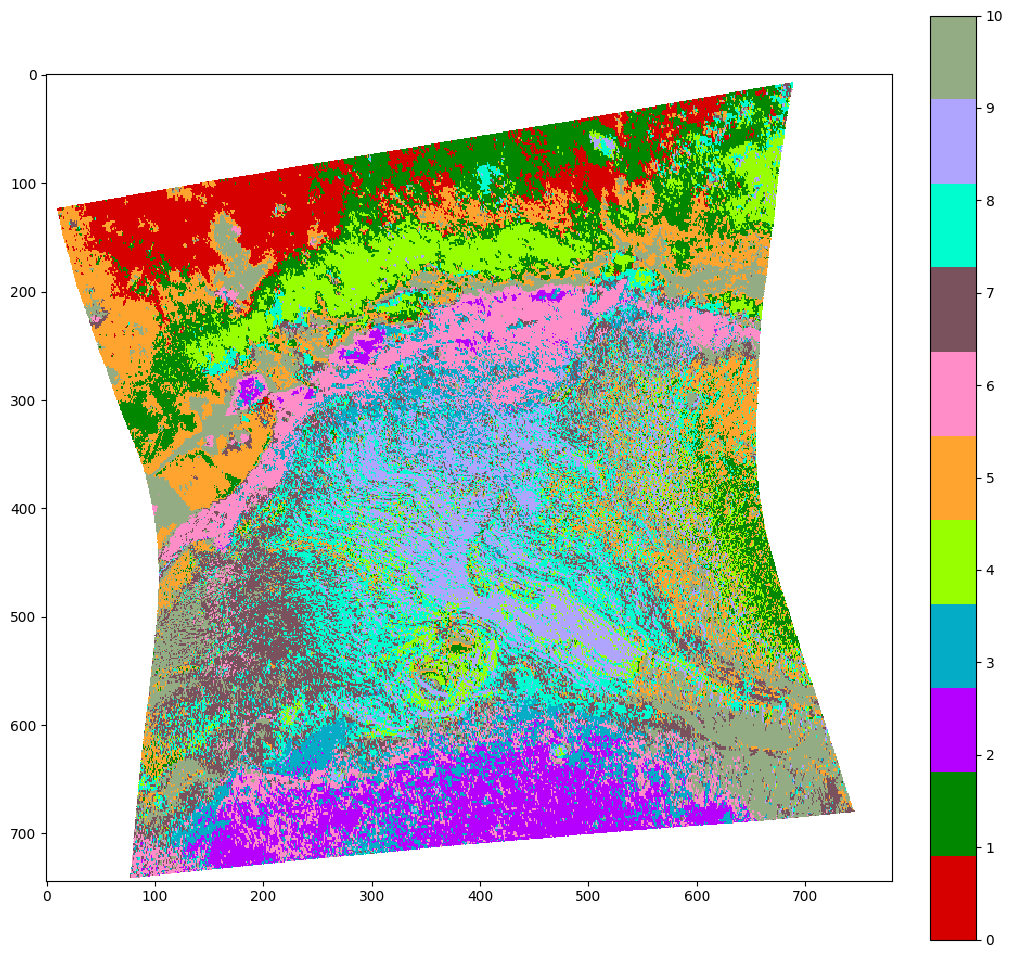

In [ ]:
fig = plt.subplots(figsize=(12,12))

#colors
color_list = cc.glasbey_light[:n_clusters]
cmap = ListedColormap(color_list)

#since the new clusters labels are based on reflectance values of a certain feature
#with a continuous color map you can shown how these values change with the class
#in that case you can uncomment the line below
#cmap = plt.cm.viridis 
 
im = plt.imshow(class_plot_df['labels'].values.reshape(img.shape[:-1]),interpolation='None',cmap=cmap) 

#color bar
cbar = plt.colorbar(im, fraction = 0.05, pad = 0.04)

#set the number of ticks on the color bar
num_ticks = n_clusters
cbar.locator = plt.MaxNLocator(num_ticks)
cbar.update_ticks() #update the color bar

plt.show()


### Export with CRS

In [ ]:
path_hdr = "data/frt00009b5a_07_if165j_mtr3.hdr" #ENVI header file
x_ul, y_ul, px, crs_wkt = read_envi_georef(path_hdr)

labels_img = class_plot_df['labels'].values.reshape(img.shape[:-1]) # labels -> 2D image
#colors
color_list = cc.glasbey_light[:n_clusters]
cmap = ListedColormap(color_list)
# Set under/over/bad values to white
cmap.set_under(color="white")
cmap.set_over(color="white")
cmap.set_bad(color=(0, 0, 0, 0))  # RGBA, alpha=0

#create discrete bins so that each integer cluster label (0..N-1)
#is mapped to a unique color without interpolation
bounds = np.arange(n_clusters + 1) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

#map integer cluster labels to RGB colors
sm = ScalarMappable(norm=norm, cmap=cmap)
#convert 2D labels array to RGBA image 
rgba = sm.to_rgba(labels_img)   
#drop alpha channel and convert to uint8 RGB           
rgb = (rgba[..., :3] * 255).astype(np.uint8)

write_cluster_geotiff(
    out_path="output/kmeans_cluster_map.tif", #change the name here!
    rgb=rgb,
    x_ul=x_ul,
    y_ul=y_ul,
    px=px,
    crs_wkt=crs_wkt
)

### Plot spectra of clusters
Plotting the median spectra of the clusters identified by the algorithm

C:\Users\francesc0\AppData\Local\Temp\ipykernel_10176\472965851.py:19: FutureWarning: The provided callable <function median at 0x000001DD528359E0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  spectra = df_nonan.groupby(labels.squeeze()).agg(np.median).T


"\npath_ = 'output/out_9b5a/spectra_df_'+filename+'_'+classifier+'_pca_umap.pkl' #uncomment to save!\n\n\nif not os.path.exists(path_): \n    \n    spectra.to_pickle(path_)\n    print('File saved!')\n\nelse: print('File already exists!')\n"

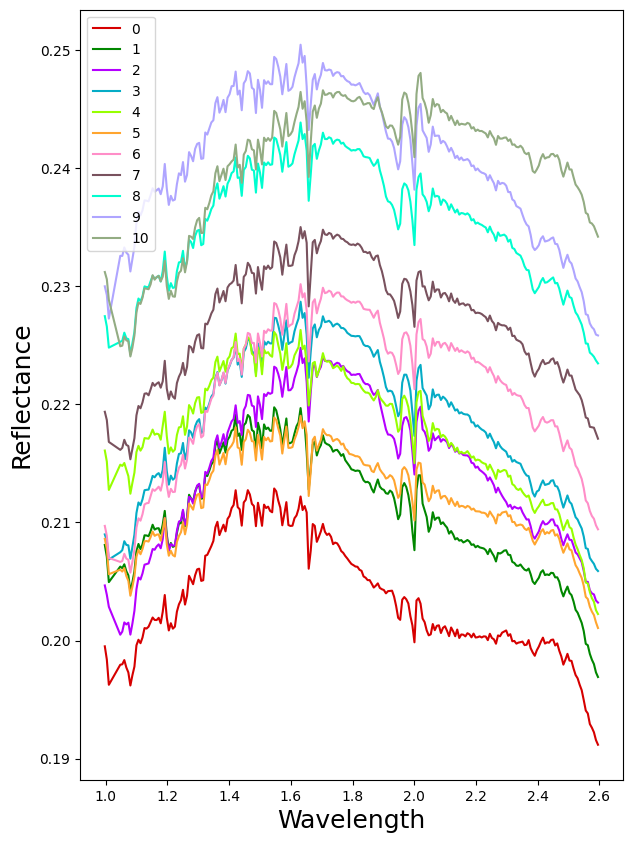

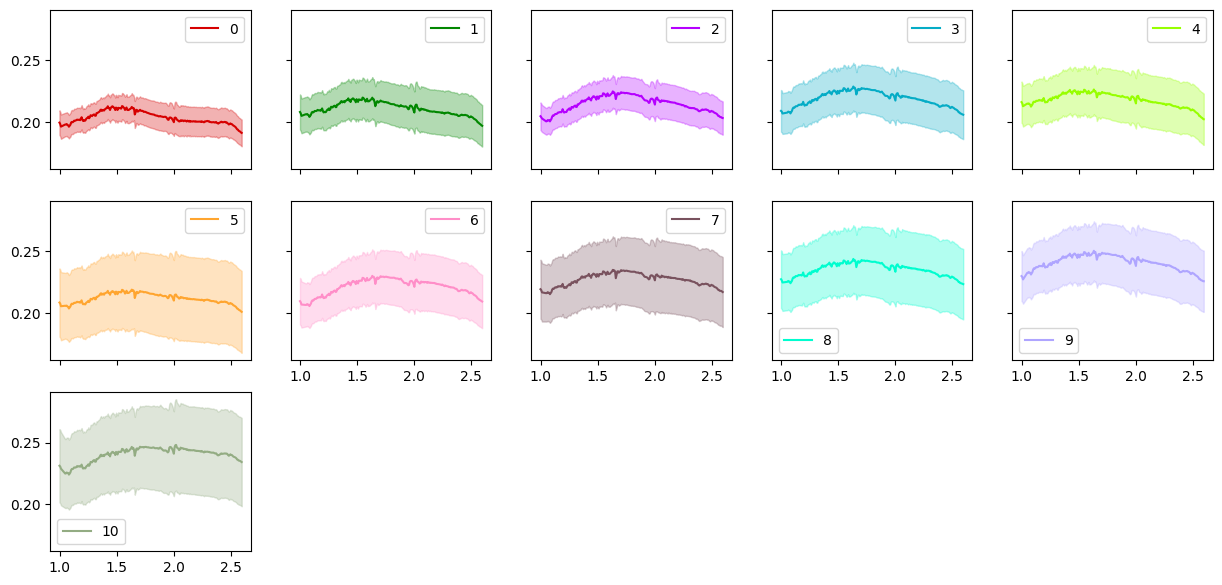

In [ ]:
start_wav, stop_wav = 1.0, 2.6 #reduce data to wavelengths between 1.0 and 2.6 microns
start_wav_ind , stop_wav_ind = find_nearest(start_wav,df.columns),find_nearest(stop_wav,df.columns)
#-------------- read df again
#using pandas dataframes
df = pd.DataFrame(img[:,:,:].reshape(-1,img.shape[-1]),
            columns=wavelength/1000.
            )
#putting rows and columns with no-data values to NaN
df[df > 1] = np.nan #no data values
#--------------
#drop nans
df_nonan = df.dropna(
    axis=0,how='all').iloc[:,start_wav_ind:stop_wav_ind]


#plot median values all in one figure--------------
spectra = df_nonan.groupby(labels.squeeze()).agg(np.median).T
ax = spectra.plot(figsize=[7,10], cmap = cmap)
#labels
ax.set_xlabel('Wavelength', fontsize=18)
ax.set_ylabel('Reflectance', fontsize = 18)


#plot each spectrum separately--------------
#calculate median and standard deviation for each cluster
grouped_data = df_nonan.groupby(labels.squeeze())
median_values = grouped_data.median()
std_values = grouped_data.std()
#plot
axs = median_values.T.plot(subplots=True, figsize=[15,12], layout = (5,5), sharey = True, cmap = cmap)
axs = axs.flatten()
for i, row in enumerate(median_values.index):
    axs[i].fill_between(median_values.columns, 
                        median_values.iloc[i,:]-std_values.iloc[i,:], 
                        median_values.iloc[i,:]+std_values.iloc[i,:], 
                        alpha=0.3, 
                        color = cmap(i))


### Save spectra of clusters

In [ ]:
#save data as a dataframe to plot later... 
path_ = 'output/spectra_PCA' + str(n_components) +'-1_'+ filename + '_'+classifier+'.pkl' #PCA - 1st component
#path_ = 'output/spectra_PCA' + str(n_components) +'_'+ filename + '_'+classifier+'.pkl' #PCA - all components
spectra.to_pickle(path_)
print('File saved!')


# Load ratioed cube
 To get a ratioed version of MTRDR cubes use the CRISM_ratioed_cube_MTRDR.ipynb notebook

In [ ]:
#path
path_if_ratioed = 'data/frt00009b5a_07_if165j_mtr3_RATIOED.hdr' #put here the path to your ratioed cube

#opening file
img_ratioed = open_image(path_if_ratioed)
#dataframe
df_ratioed = pd.DataFrame(img_ratioed[:,:,:].reshape(-1,img_ratioed.shape[-1]),
            columns=wavelength/1000.
            )
#drop nans
df_ratioed = df_ratioed.dropna(axis=0,how='all').iloc[:,start_wav_ind:stop_wav_ind]

### Plot

C:\Users\francesc0\AppData\Local\Temp\ipykernel_10176\2434314983.py:10: FutureWarning: The provided callable <function nanmedian at 0x000001DD52841260> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  spectra_ratioed = df_ratioed.groupby(labels.squeeze()).agg(np.nanmedian).T


"\npath_ = 'output/out_9b5a/spectra_ratioed_'+filename+'_'+classifier+'_pca_umap.pkl' #uncomment to save!\n\n\nif not os.path.exists(path_): \n    \n    spectra.to_pickle(path_)\n    print('File saved!')\n\nelse: print('File already exists!')\n"

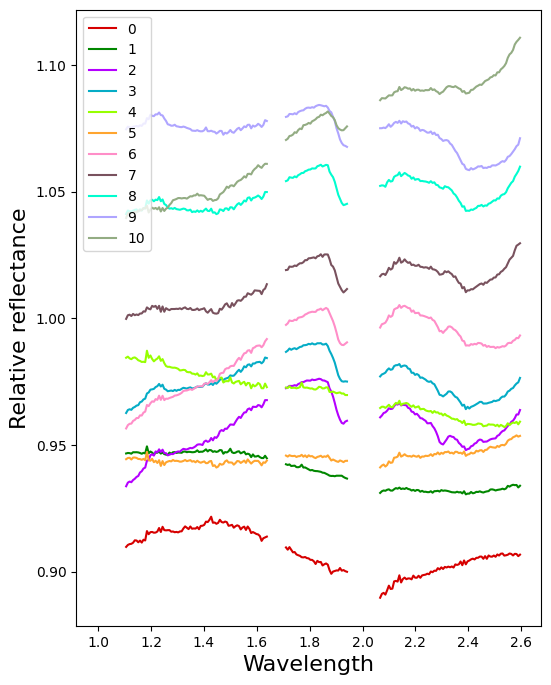

In [ ]:
#plot

#mask artefacts
df_ratioed.loc[:,start_1:stop_1] = np.nan #1.7 filter artefact
df_ratioed.loc[:,start_2:stop_2] = np.nan #CO2 artefact

#mask first part of spectrum
df_ratioed.loc[:,1:1.1] = np.nan

spectra_ratioed = df_ratioed.groupby(labels.squeeze()).agg(np.nanmedian).T
ax = spectra_ratioed.plot(figsize=[6,8], cmap = cmap)

#uncomment for smoothing
'''
from scipy.signal import savgol_filter
#smoothed_spectra = savgol_filter(spectra_ratioed, 5, 2, axis = 0)
#smoothed_spectra_df = pd.DataFrame(smoothed_spectra, index = spectra_ratioed.index, columns = spectra_ratioed.columns)

#ax = smoothed_spectra_df.plot(figsize=[7,10], cmap = cmap)
'''

ax.set_xlabel('Wavelength', fontsize=16)
ax.set_ylabel('Relative reflectance', fontsize = 16)



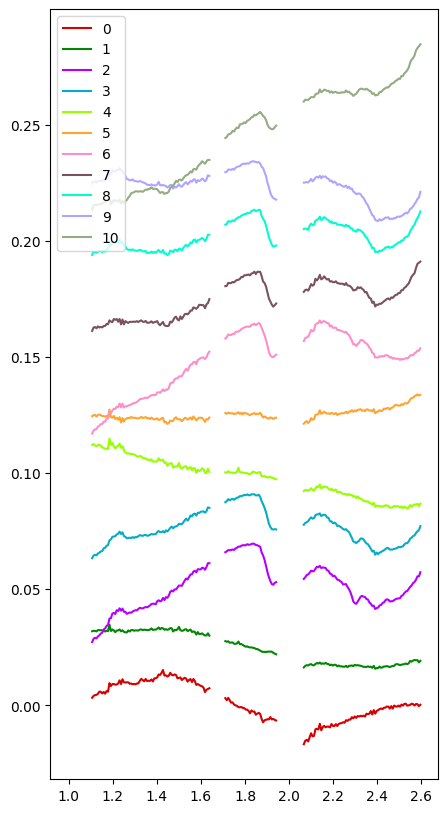

In [35]:
#plot with a sistematic shift

r = [r/40.0 for r in range(0,len(spectra_ratioed.columns))] #shift
ratioed_spectra_shift_df = spectra_ratioed-spectra_ratioed.median()+r
ax = ratioed_spectra_shift_df.plot(figsize=[5,10], cmap = cmap)